### EDA

#### Data
- The dataset contains 1,000 observations and a binary target variable, "Credit risk"
- There are no missing values or duplicate records
- The target variable is moderately imbalanced (70:30)
- The dataset does not include a meaningful temporal dimension (e.g., date)

#### Process
- I mapped the "Credit risk" from Good:1 Bad:2 to Good:0 Bad:1
- I performed the stratified randomised train_test_split (no EDA was performed on the test split)
- To better understand the data I used 4 custom plot functions:

    - "plot_binary_distribution" - for plotting the target variable only

    - "plot_bars_abs" (mainly for categorical features)
        - for a given feature it shows the count for each category split by target variable
            - in-graph labels: count of loans, % of all loans, % of all bad/good loans, % of bad/good loans within the category

    - "plot_bars_rel" (mainly for numerical features)
        - for a given feature, it bins the feature values and plots within each bin the bad loan rate. Bar width reflects the count of loans
            - in-graph labels: count of loans, % of all loans, % of all bad loans, % of bad loans within the bin

    - "plot_bad_loans_rate_heatmap" (for interactions between features)
        - For a pair of features, it displays a matrix of bad loan rates across combinations of their categories (or bins for numerical features).
            - in-graph labels: bad loans rate, count of bad loans, count of all loans

    - "plot_cramers_v_heatmap" - to determine the strength of association between categorical (and numerical binned) variables


#### Findings and Summary

- One feature (Number of Accounts) was discarded as it directly replicates the target variable

- Several features demonstrate strong explanatory power, particularly:
    - Status of existing checking account
    - Housing
    - Duration in months
    - Credit history
    
    These features show clear separation from the baseline bad loan rate and meaningful category-level differences

- A second group of features shows moderate predictive power, including:

    - Other installment plans
    - Savings account/bonds
    - Credit amount
    - Purpose
    - Age
    
    These features provide useful signal, though effects are less pronounced or partially driven by smaller categories/segments

- Some features exhibit limited explanatory power, with weak or inconsistent patterns:

    - Personal status and sex
    - Property
    - Present employment since
    - Job

- Several features show little to no predictive value, as their distributions are close to the baseline across categories/segments:

    - Installment rate in percentage of diposable income
    - Other debtors / guarantors
    - Present residence since
    - Telephone
    - Foreign worker
    - Number of existing credits
    - Number of people liable to provide maintenance for

- In general, risk is not uniformly distributed, but concentrated in specific segments (e.g., longer loan durations, certain account statuses, younger borrowers)

- Some features show monotonic or non-linear relationships with the target, suggesting that:

    - binning
    - or tree-based models
may be beneficial


- Analyzing the interactions between features has shown:
    - there are no obvious strong interactions between features
        - no clear strong interaction effects, as no feature pair shows a significantly higher bad rate (with meaningful frequency) compared to the individual features
    - Pearsons correlation heatmap (for numerical features) shows low correlation among numerical (and ordinal/numerical-like) features; Credit amount and Duration in months exhibit a somewhat stronger correlation, which is intuitive.

    - The Cramér’s V heatmap indicates no strong associations between categorical features. The only exception is Housing and Property, which show a moderate relationship, as expected.

    - Monthly payment (Credit amount/Duration in months) might have predictive power

#### Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from utils import (plot_bars_abs, 
                   plot_bars_rel, 
                   plot_binary_distribution, 
                   plot_bad_loans_rate_heatmap, 
                   plot_cramers_v_heatmap)


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df = pd.read_csv('../data/dataset.csv', index_col=0)
X = df.drop("Credit risk", axis=1)
y = df["Credit risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df["Credit risk"] = train_df["Credit risk"].map({1: 0, 2: 1})
test_df["Credit risk"] = test_df["Credit risk"].map({1: 0, 2: 1})

train_df.head()

,Status of existing checking account,Duration in months,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,Present residence since,Property,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Number of Accounts,Credit risk
828,A11,36,A32,A41,8335,A65,A75,3,A93,A101,4,A124,47,A143,A153,1,A173,1,A191,A201,2,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,1,0
148,A11,36,A34,A42,5371,A61,A73,3,A93,A103,2,A122,28,A143,A152,2,A173,1,A191,A201,1,0
735,A12,36,A31,A44,3990,A65,A72,3,A92,A101,2,A124,29,A141,A152,1,A171,1,A191,A201,1,0
130,A12,48,A32,A40,8487,A65,A74,1,A92,A101,2,A123,24,A143,A152,1,A173,1,A191,A201,1,0


#### Checking for duplicates

In [2]:
print('Row duplicates: ', df.duplicated().any())
print('Column duplicates: ', df.columns.duplicated().any())

Row duplicates:  False
Column duplicates:  False


#### Checking for missing values

In [3]:
for i in list(train_df.columns):
    print(i, f"-  Has missing values:  {train_df[i].isna().any()}")

Status of existing checking account -  Has missing values:  False
Duration in months -  Has missing values:  False
Credit history -  Has missing values:  False
Purpose -  Has missing values:  False
Credit amount -  Has missing values:  False
Savings account/bonds -  Has missing values:  False
Present employment since -  Has missing values:  False
Installment rate in percentage of disposable income -  Has missing values:  False
Personal status and sex -  Has missing values:  False
Other debtors / guarantors -  Has missing values:  False
Present residence since -  Has missing values:  False
Property -  Has missing values:  False
Age in years -  Has missing values:  False
Other installment plans -  Has missing values:  False
Housing -  Has missing values:  False
Number of existing credits at this bank -  Has missing values:  False
Job -  Has missing values:  False
Number of people being liable to provide maintenance for -  Has missing values:  False
Telephone -  Has missing values:  False

#### Feature Typing
<b>Categorical</b>
- Status of existing checking account -  Categories: 4  ['A14', 'A13', 'A12', 'A11']
- Credit history - Categories: 5 ['A34','A33', 'A32', 'A31', 'A30']
- Purpose - Categories: 10 ['A49', 'A46', 'A41', 'A40', 'A43', 'A42', 'A45', 'A44', 'A410', 'A48']
- Savings account/bonds - Categories: 5 ['A61', 'A63', 'A65', 'A62', 'A64']
- Present employment since - Categories: 5  ['A75', 'A72', 'A73', 'A74', 'A71'] -  numerical but encoded as categorical
- Installment rate in percentage of disposable income - Categories: 4 [1 2 3 4] -  numerical but encoded as categorical
- Personal status and sex - Categories: 4 ['A93', 'A91', 'A92', 'A94'] 
- Other debtors / guarantors - Categories: 4 ['A101', 'A102', 'A103']
- Present residence since - Categories: 4 [1 2 3 4] -  numerical but encoded as an categorical  (maybe ordinal)
- Property -  Categories:4 ['A124', 'A123', 'A122', 'A121']
- Other installment plans - Categories 3 ['A143', 'A141', 'A142']
- Housing - Categories:4 ['A152', 'A151', 'A153']
- Job - Categories:4  ['A173', 'A174', 'A172', 'A171']
- Telephone - Categories:4 ['A192', 'A191'] - Binary variable
- Foreign worker - Categories:4 ['A201', 'A202']

<b>Numerical</b>
- Duration in months - min:4 max: 60
- Credit amount - min:250  max:18424
- Age in years - min:19 max:75
- Number of existing credits at this bank - min:1 max:4
- Number of Accounts - min:1 max:2
- Number of people being liable to provide maintenance for - min:1 max:2


<b>NOTES</b>

- Installment rate in percentage of disposable income, Present employment since, Present residence since - All numerical features but are encoded as categorical
- Number of existing credits at this bank - could be a Binned/Categorical variable but I decided to treat it as numerical
- Number of Accounts - might be a binary variable but I model it as numerical (Assuming there is no cap on the number of accounts a client might have)



#### Target variable distribution

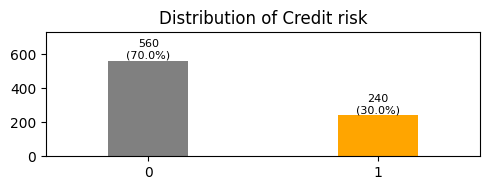

In [4]:
plot_binary_distribution(train_df, bar_width=0.35)

#### Feature 1: Status of existing checking account (Categorical)
- Categories A11 and A12 have a bad loan rate well above the 30% baseline
- Category A14 is dominant in size and has a bad loan rate well below the 30% baseline (~12%)
- The feature shows solid explanatory power


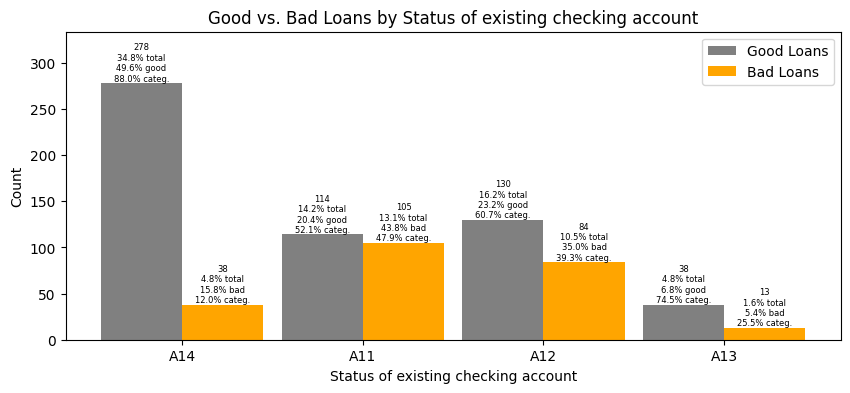

In [5]:
plot_bars_abs(feature = "Status of existing checking account", df = train_df, label_fontsize =6, figsize=(10,4))

#### Feature 2: Credit History (Categorical)
- Category A34 is large in size and has a bad loan rate well bellow the 30% baseline (~17%)
- Categories A30 and A31 have above baseline % of bad loans, however their frequencies are small
- Overall, the feature seems to have solid explanatory power

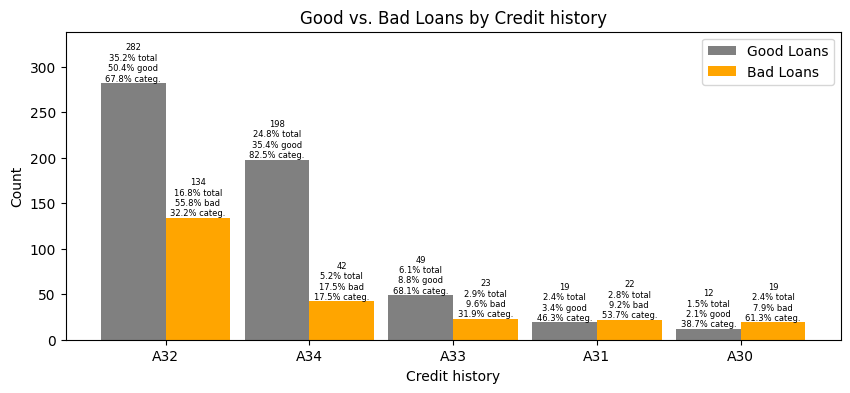

In [6]:
plot_bars_abs( df = train_df, feature = "Credit history",label_fontsize =6, figsize=(10,4))

#### Feature 3: Purpose (Categorical)
- Categories A43 and A41 both have a bad loan rate well below baseline (~20%)
- Categories A40 has a clear above baseline % of bad loans. The same applies for categories A49 and A46 howewer their frequencies are smaller
- The feature seems to have moderate explanatory power

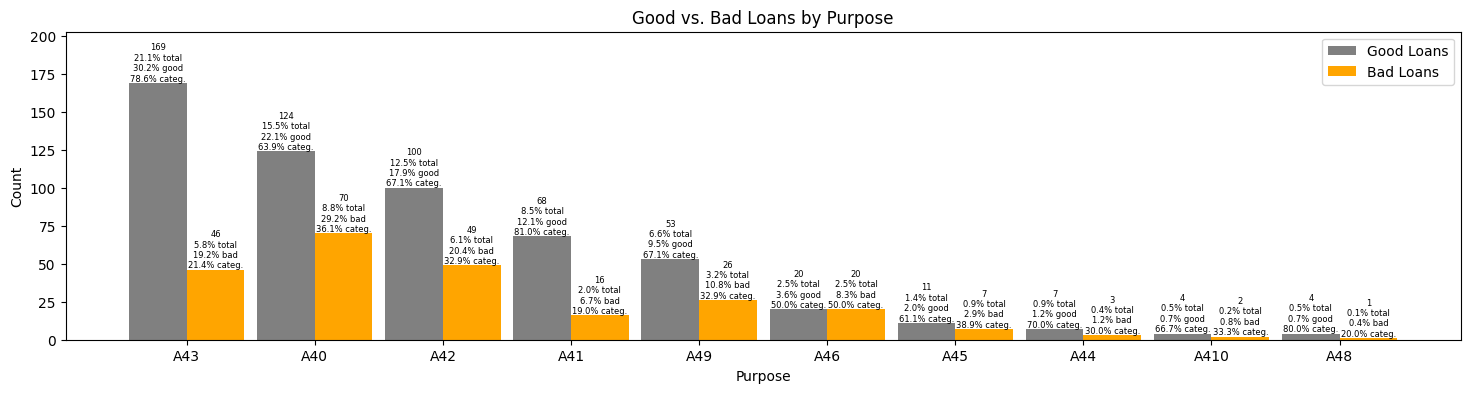

In [7]:
plot_bars_abs( df = train_df, feature = "Purpose", label_fontsize =6, figsize=(18,4))

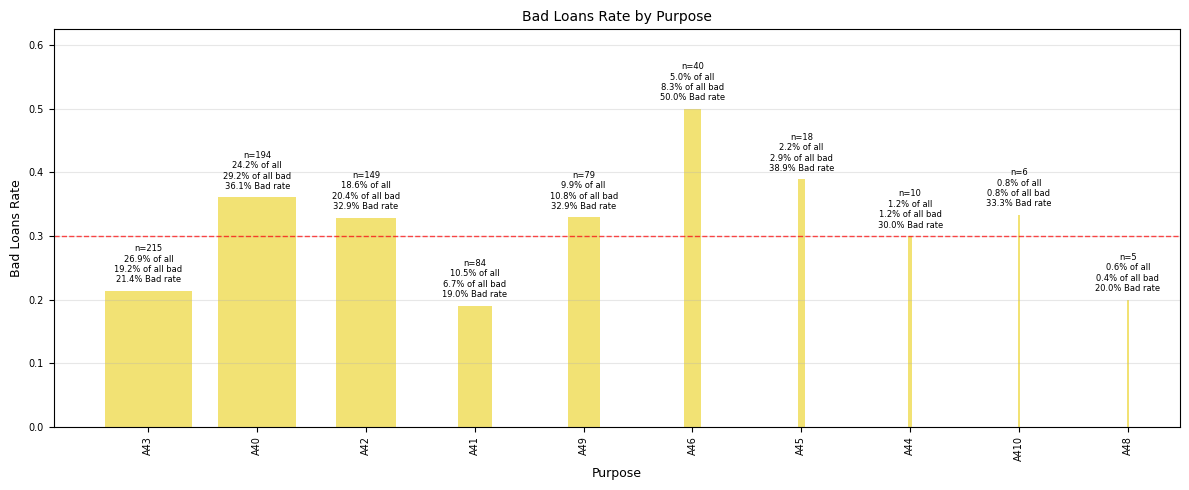

In [8]:
plot_bars_rel( df = train_df, feature = "Purpose", feature_type = "categorical", hline = 0.3)

#### Feature 4: Savings account/bonds (Categorical)
- Bad loans rate is above baseline for categories A61 and A62, and well below baseline for categores A63, A64, and A65
- Feature seems to have moderate explanatory power

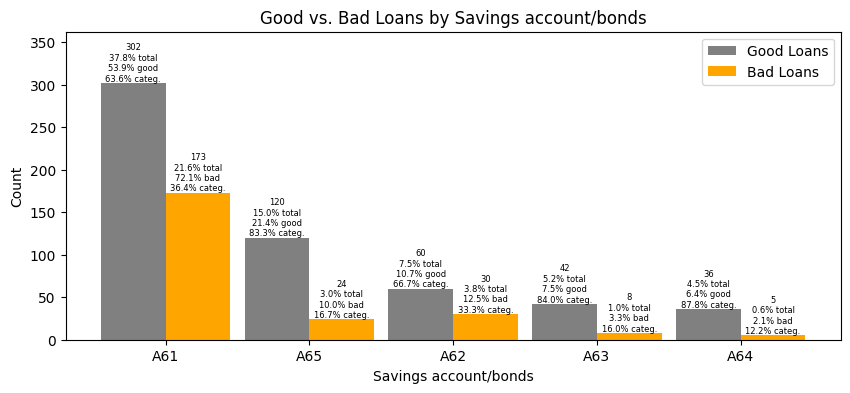

In [9]:
plot_bars_abs(feature = "Savings account/bonds", df = train_df, label_fontsize =6, figsize=(10,4))
#plot_bars_rel( df = train_df, feature = "Savings account/bonds", feature_type = "categorical", hline = 0.3)

#### Feature 5: Present employment since (Categorical)
- Categories A74 and A75 have a below baseline % of bad loans
- Categories A72 and A71 have an above baseline % of bad loans, however their frequencies are not large
- This feature seems to have small explanatory power

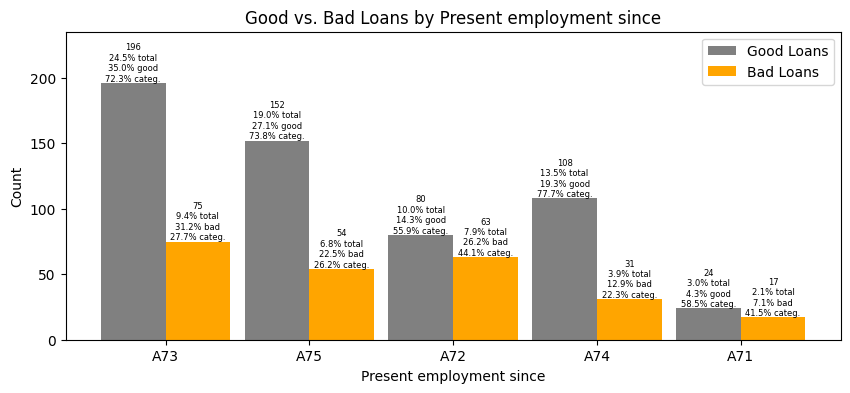

In [10]:
plot_bars_abs(feature = "Present employment since", df = train_df, label_fontsize =6, figsize=(10,4))
#plot_bars_rel( df = train_df, feature = "Present employment since", feature_type = "categorical", hline = 0.3)

#### Feature 6: Installment rate in percentage of disposable income (Categorical)
- All categories of this feature seem to be very close to baseline % of bad loans (~30%)
- The feature doesn't appear to have much explanatory power

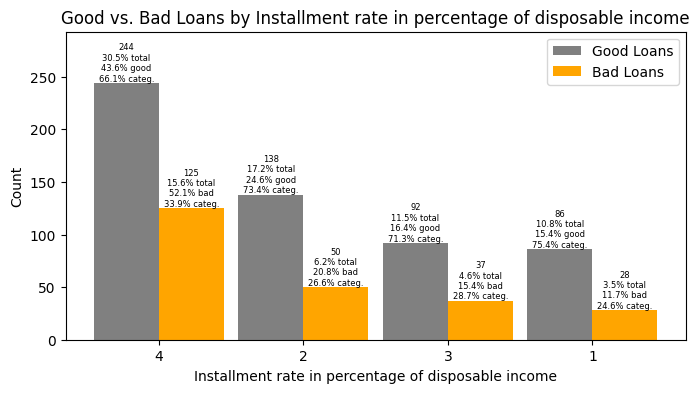

In [11]:
plot_bars_abs(feature = "Installment rate in percentage of disposable income", df = train_df, label_fontsize =6, figsize=(8,4))
#plot_bars_rel( df = train_df, feature = "Installment rate in percentage of disposable income", feature_type = "categorical", hline = 0.3)

#### Feature 7: Personal status and sex (Categorical)
- Category A92 has above baseline % of bad loans, while A93 has below baseline bad loan rate
- The feature seems to have some explantory power

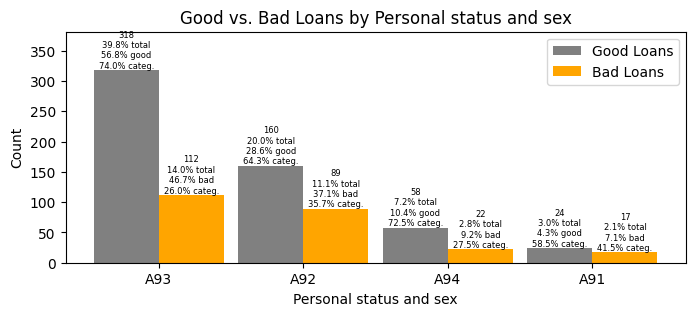

In [12]:
plot_bars_abs(feature = "Personal status and sex", df = train_df, label_fontsize =6, figsize=(8,3))
#plot_bars_rel( df = train_df, feature = "Personal status and sex", feature_type = "categorical", hline = 0.3)

#### Feature 8: Other debtors / guarantors (Categorical)
- The category A101 dominates this feature and it is well balanced (~30% of bad loans)
- The feature doesn't seem to have much explanatory power

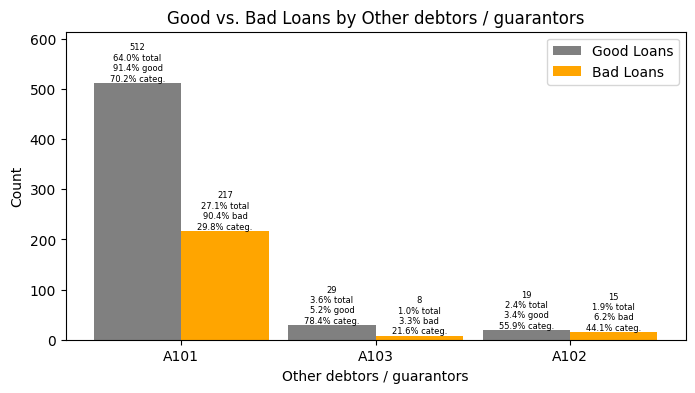

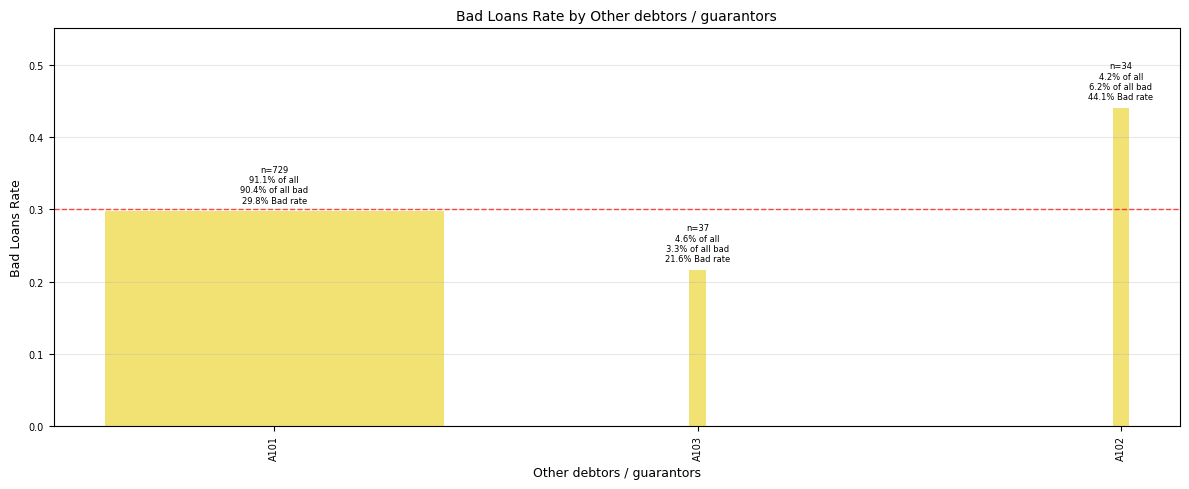

In [13]:
plot_bars_abs(feature = "Other debtors / guarantors", df = train_df, label_fontsize =6, figsize=(8,4))
plot_bars_rel( df = train_df, feature = "Other debtors / guarantors", feature_type = "categorical", hline = 0.3)

#### Feature 9: Present residence since (Categorical)
- The % of bad loans seems to be well balanced accross the categories
- The feature doesn't seem to have predictive power

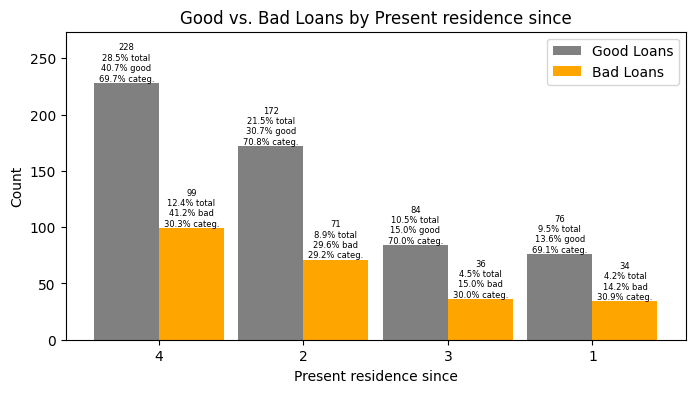

In [14]:
plot_bars_abs(feature = "Present residence since", df = train_df, label_fontsize =6, figsize=(8,4))
#plot_bars_rel( df = train_df, feature = "Present residence since", feature_type = "categorical", hline = 0.3)

#### Feature 10: Property (Categorical)
- Categories A121 and A124 have below/above baseline % of bad loans, respectively
- Overall the feature seems to have some predictive power

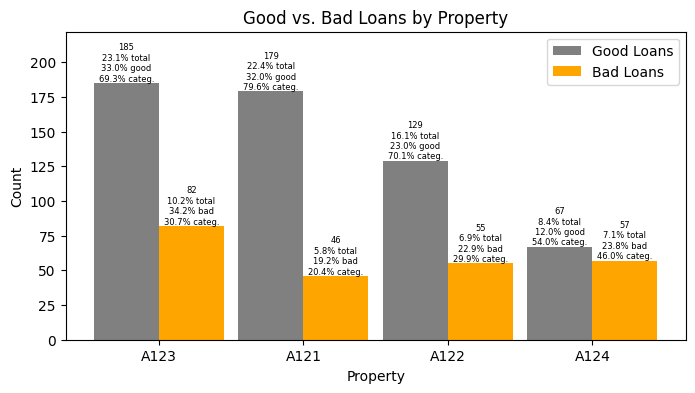

In [15]:
plot_bars_abs(feature = "Property", df = train_df, label_fontsize =6, figsize=(8,4))
#plot_bars_rel( df = train_df, feature = "Property", feature_type = "categorical", hline = 0.3)

#### Feature 11: Other installment plans (Categorical)
- Category A141 has a strong above baseline % of bad loans (42%) and it holds around of 20% of all bad loans
- This feature seems to have moderate explanatory power

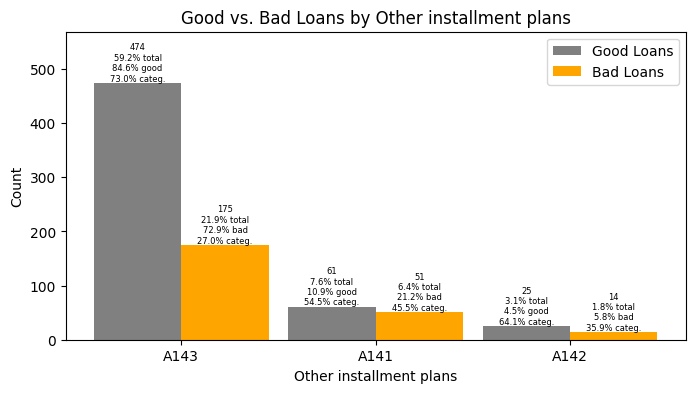

In [16]:
plot_bars_abs(feature = "Other installment plans", df = train_df, label_fontsize =6, figsize=(8,4))
#plot_bars_rel( df = train_df, feature = "Other installment plans", feature_type = "categorical", hline = 0.3)

#### Feature 12: Housing (Categorical)
- Features A151 and A153 both have above baseline % of bad loans (~40%) and together they make up ~40% of bad loans
- This feature has solid explanatory power

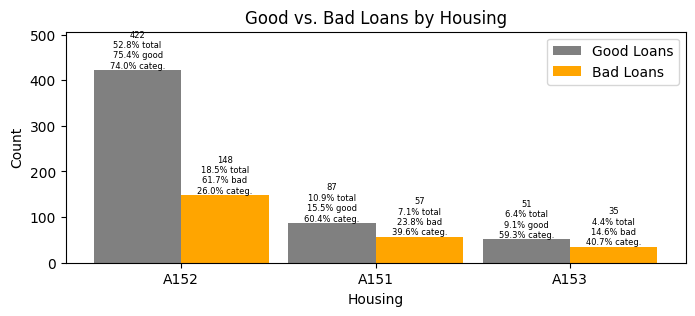

In [17]:
plot_bars_abs(feature = "Housing", df = train_df, label_fontsize =6, figsize=(8,3))
#plot_bars_rel(df = train_df, feature = "Housing", feature_type = "categorical", hline = 0.3)

#### Feature 13: Job (Categorical)
- Categories A171 and A174 have somewhat higher % of bad loans (25% and 35%)
- Overall this feature doesnt seem to reveal much

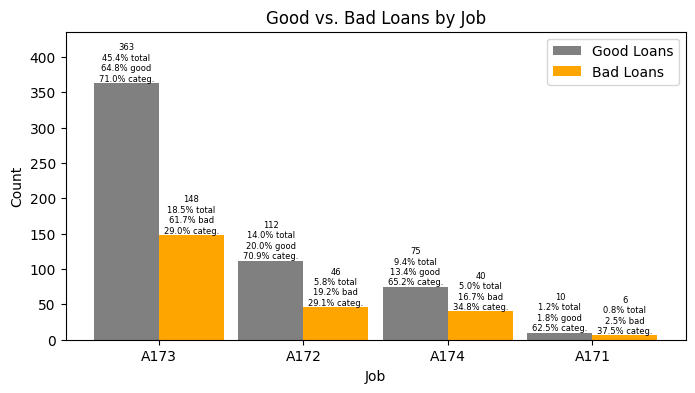

In [18]:
plot_bars_abs(feature = "Job", df = train_df, label_fontsize =6, figsize=(8,4))
#plot_bars_rel( df = train_df, feature = "Job", feature_type = "categorical", hline = 0.3)

#### Feature 14: Telephone (Categorical)
- There is minor difference in % of bad loans between the categories
- The feature doesn't seem to have any explanatory power

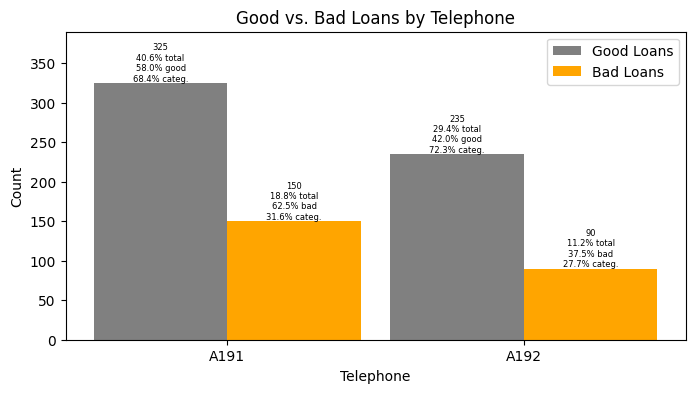

In [19]:
plot_bars_abs(feature = "Telephone", df = train_df, label_fontsize =6, figsize=(8,4))
#plot_bars_rel( df = train_df, feature = "Telephone", feature_type = "categorical", hline = 0.3)

#### Feature 15: Foreign worker(Categorical)
- Category A201 takes up 99% of all observations and its bad loan rate is very close to the 30% baseline
- The feature doesn't seem to have explanatory power

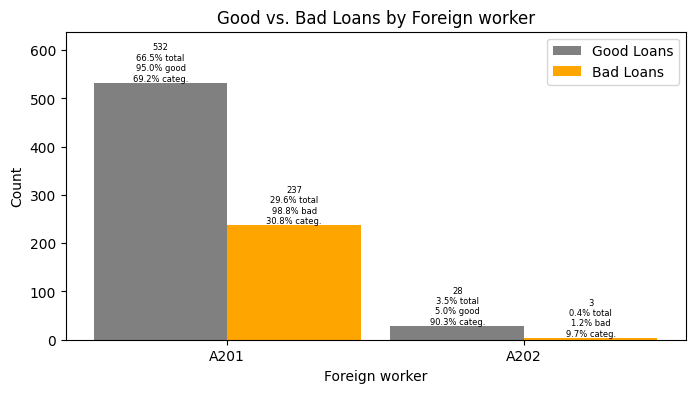

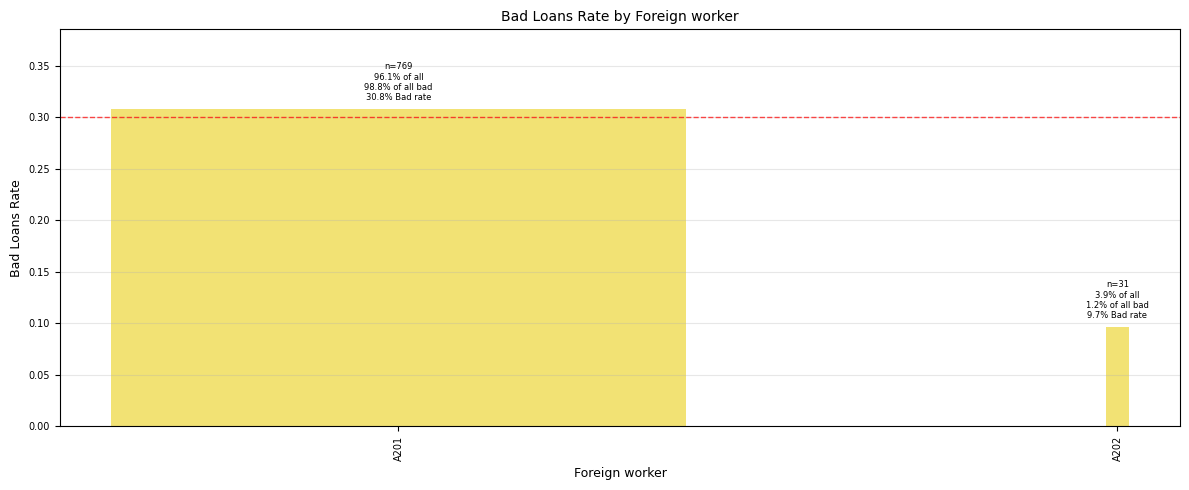

In [20]:
plot_bars_abs(feature = "Foreign worker", df = train_df, label_fontsize =6, figsize=(8,4))
plot_bars_rel( df = train_df, feature = "Foreign worker", feature_type = "categorical", hline = 0.3)

#### Feature 16: Duration in months (Numerical)
- Bad loans rate seems to be increasing with loan duration 
- Loan durations below 36 months have a below/at baseline bad loan rate(15%-30%)
- Loan durations between 36 and 60 months seem to have a visibly higher bad loan rate (30%-60%)
- The feature displays solid predictive power

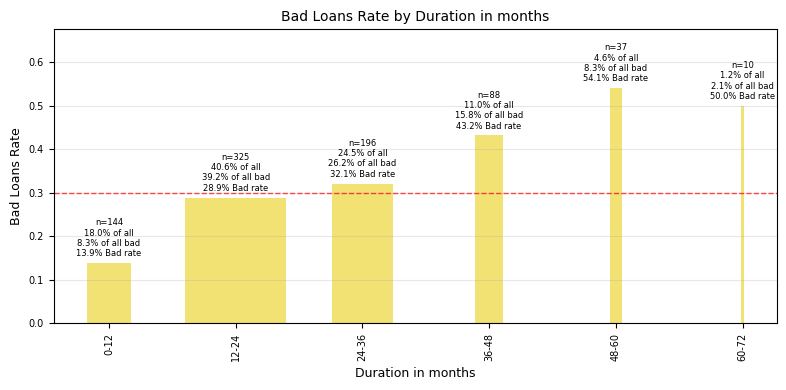

In [21]:
plot_bars_rel(df = train_df, 
                                 feature = "Duration in months", 
                                 bucket_size=12, 
                                 figsize=(8,4),
                                 hline=0.3)

#### Feature 17: Credit Amount (Numerical)
- It appears the bad loan rate is first falling until a certian threshold an then increasing with the loan size
- However, the larger the loan size the fewer loans there are - it is hard to say if this is signal or noise
- The feature appears to have some predictive power


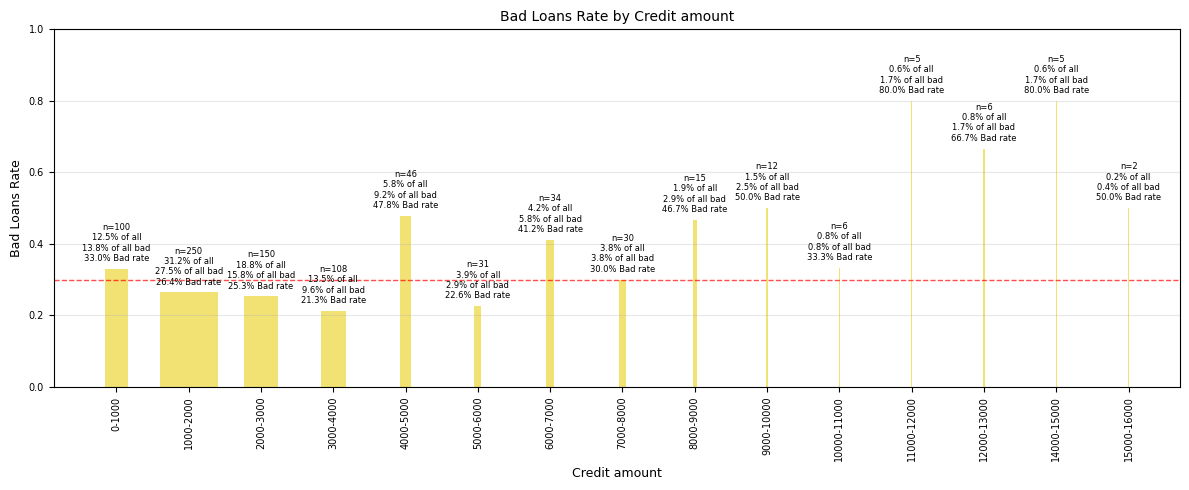

In [22]:
plot_bars_rel(df = train_df, 
              feature = "Credit amount", 
              amount_limit = 100000, 
              bucket_size=1000, 
              hline=0.3)

#### Feature 18: Age in Years (Numerical)
- Younger age groups (age group 20-30 as well as 10-20) have a bad loans % higher than the baseline
- Age group 20-30 makes up for 36% of all loans and 42% of all bad loans
- All other age groups have a bad loan rate lower than baseline 
- The feature seems to have moderate predictive power

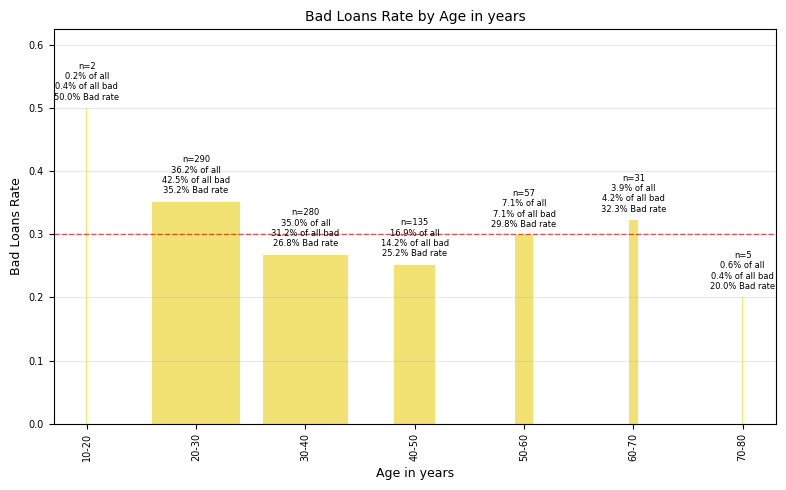

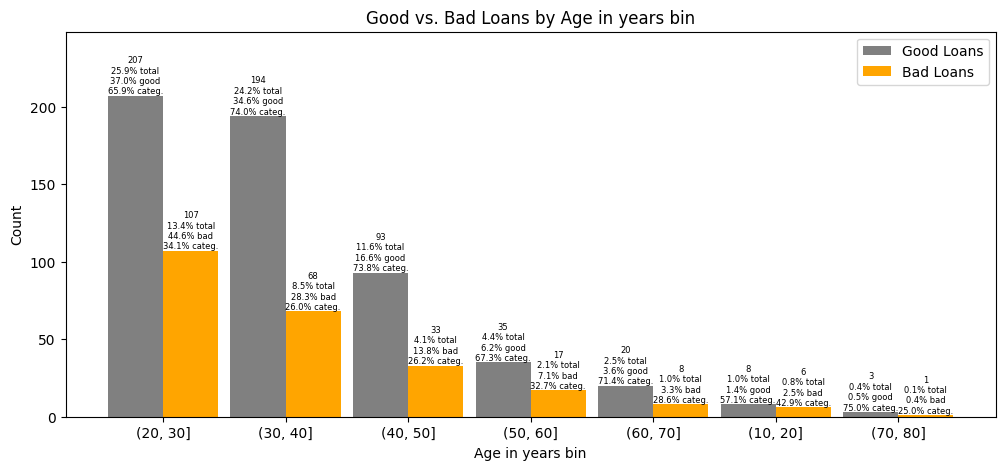

In [23]:
train_df["Age in years bin"] = pd.cut(train_df[ "Age in years"], bins=range(0, int(train_df[ "Age in years"].max()) + 10, 10))

plot_bars_rel(df = train_df, 
                        feature = "Age in years", 
                        bucket_size=10, 
                        figsize=(8,5),
                        hline=0.3)

plot_bars_abs(df = train_df, 
                      feature = "Age in years bin", 
                      figsize=(12,5),
                      label_fontsize=6
                      )


#### Feature 19: Number of Account (Numerical)
- This feature is an exact replica of the target variable - this is likely a bug/data leakage
- This feature should be removed from the dataset

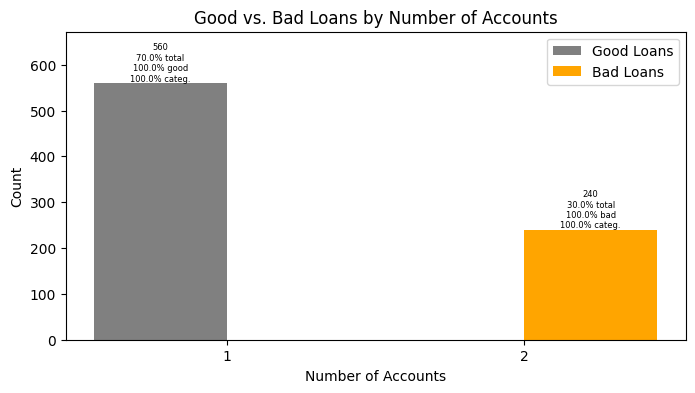

In [24]:
plot_bars_abs(feature = "Number of Accounts", df = train_df, label_fontsize =6, figsize=(8,4))

#### Feature 20: Number of existing credits at this bank (Numerical/ maybe Binary)
- Almost all observations have 1-2 existing credits, their bad loan rate is very close to baseline 30%
- The feature appears to have little/no predictive power


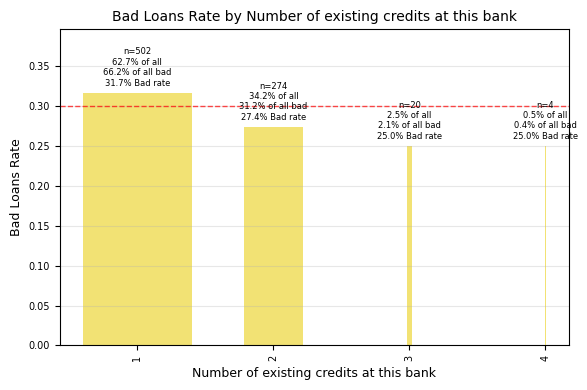

In [25]:
plot_bars_rel(df = train_df, 
                    feature = "Number of existing credits at this bank", 
                    short_x_labels=True,
                    bucket_size=1, 
                    figsize=(6,4),
                    hline=0.3)

#### Feature 21: Number of people being liable to provide maintenance for
- Apparently all loan takers in the portfolio have 1-2 people they are liable for, bad loan rate in both cases is very close to baseline
- The feature appears to have no predictive power

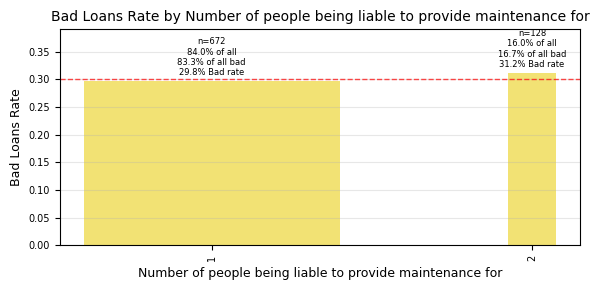

In [26]:
plot_bars_rel(df = train_df, 
                feature = "Number of people being liable to provide maintenance for", 
                short_x_labels=True,
                bucket_size=1, 
                figsize=(6,3),
                hline=0.3)

## Interactions

#### Bad Loan Rate Across Category Intersections


- A heatmap of pairwise category interactions was constructed for selected feature combinations

- The objective was to identify category intersections that exhibit:

    - sufficient sample size (e.g. ≥50 loans, given a training set of ~800 observations)
    - elevated bad loan rates (e.g. ≥40%)

- Numerical features were discretized into bins and treated as categorical variables

- Findings:
    - No strong interaction effects were identified; category intersections do not exhibit materially higher bad loan rates beyond what is explained by individual feature effects


In [27]:
# preparng the data for the heatmap (binning numerical features)

categorical_columns = [
    "Status of existing checking account",
    "Credit history",
    "Purpose",
    "Savings account/bonds",
    "Present employment since",
    "Installment rate in percentage of disposable income",
    "Personal status and sex",
    "Other debtors / guarantors",
    "Present residence since",
    "Property",
    "Other installment plans",
    "Housing",
    "Job",
    "Telephone",
    "Foreign worker"
]
# binning numerical features
train_df["Credit amount bin"] = pd.cut(train_df[ "Credit amount"], bins=range(0, int(train_df[ "Credit amount"].max()) + 2000, 2000))
train_df["Duration in months bin"] = pd.cut(train_df[ "Duration in months"], bins=range(0, int(train_df[ "Duration in months"].max()) + 12, 12))
train_df["Age in years bin"] = pd.cut(train_df[ "Age in years"], bins=range(0, int(train_df[ "Age in years"].max()) + 10, 10))

numerical_columns = [
    "Credit amount bin",
    "Duration in months bin",
    "Age in years bin",
    "Number of existing credits at this bank",
    "Number of people being liable to provide maintenance for"
]

all_columns = categorical_columns + numerical_columns

In [28]:
# Make a subset of all feature combinations (otherwise there would be too many plots to analyze)

from itertools import combinations

pairs = list(combinations(all_columns, 2))

# FILTER SETTINGS
min_bad_count = 50
min_bad_rate = 0.4

valid_pairs = []

for feature_x, feature_y in pairs:
    signal = plot_bad_loans_rate_heatmap(
        train_df,
        feature_x,
        feature_y,
        min_bad_count_filter=min_bad_count,
        min_bad_rate_filter=min_bad_rate,
        return_signal=True
    )

    if signal:
        valid_pairs.append((feature_x, feature_y))

print(f"Total pairs: {len(pairs)}")
print(f"Filtered pairs: {len(valid_pairs)}")

Total pairs: 190
Filtered pairs: 24


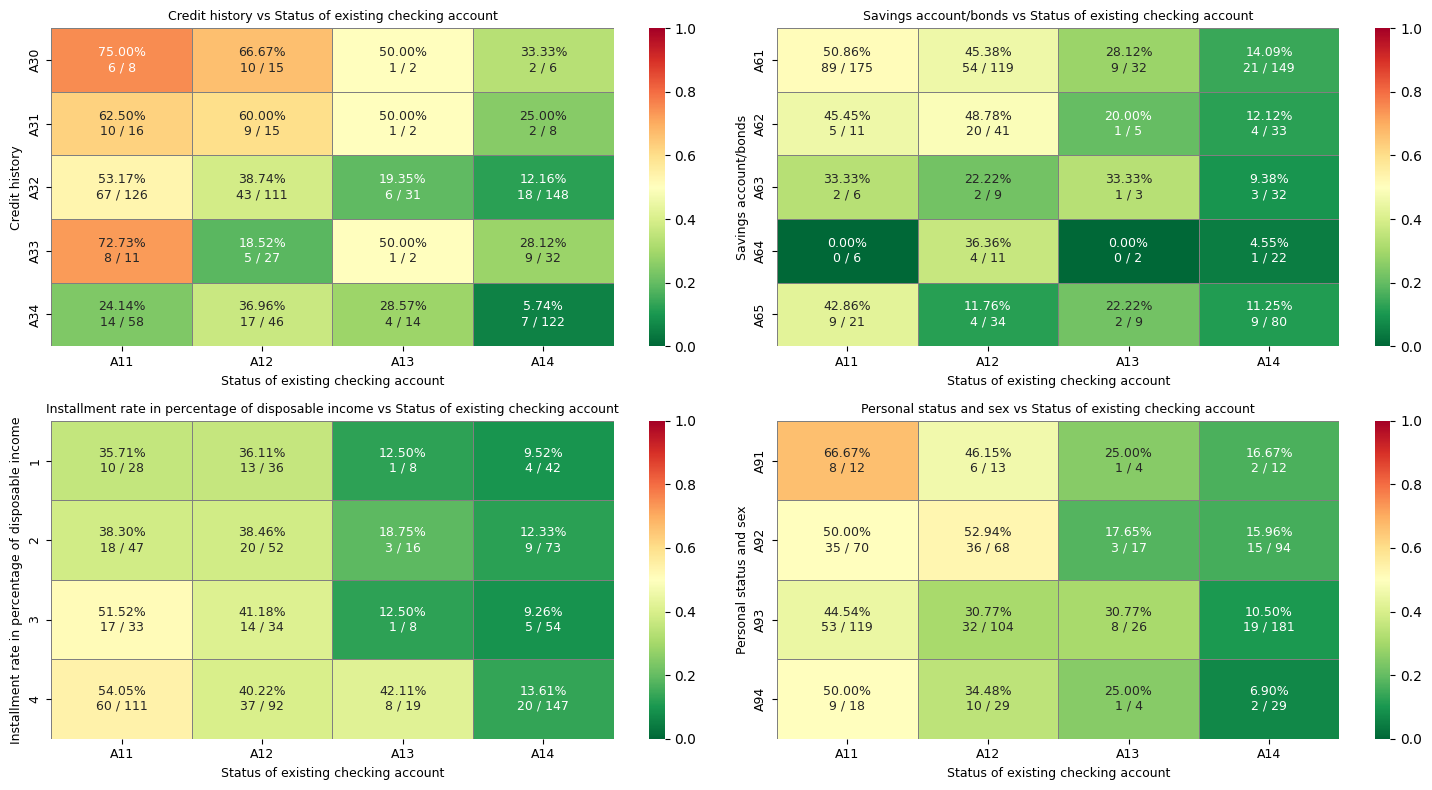

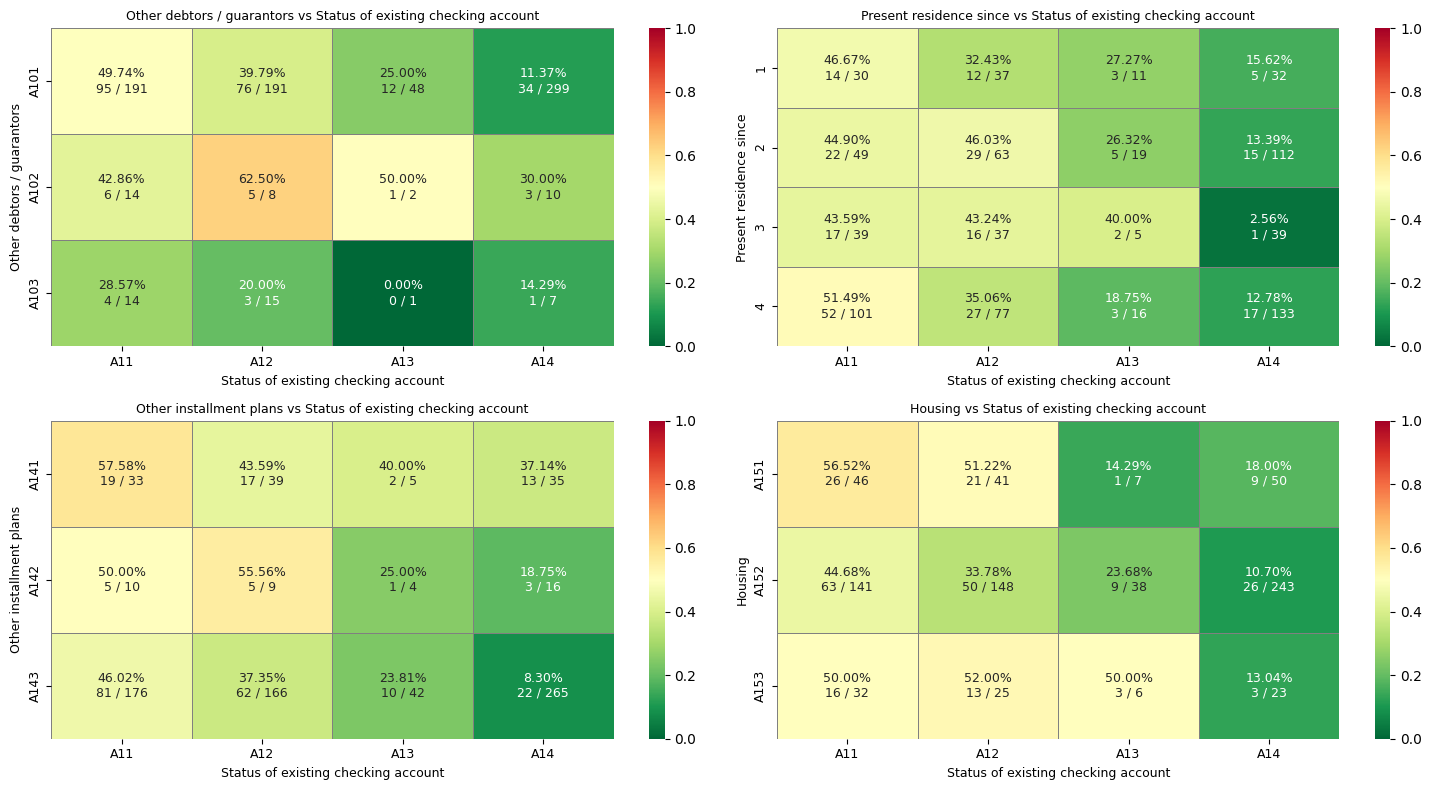

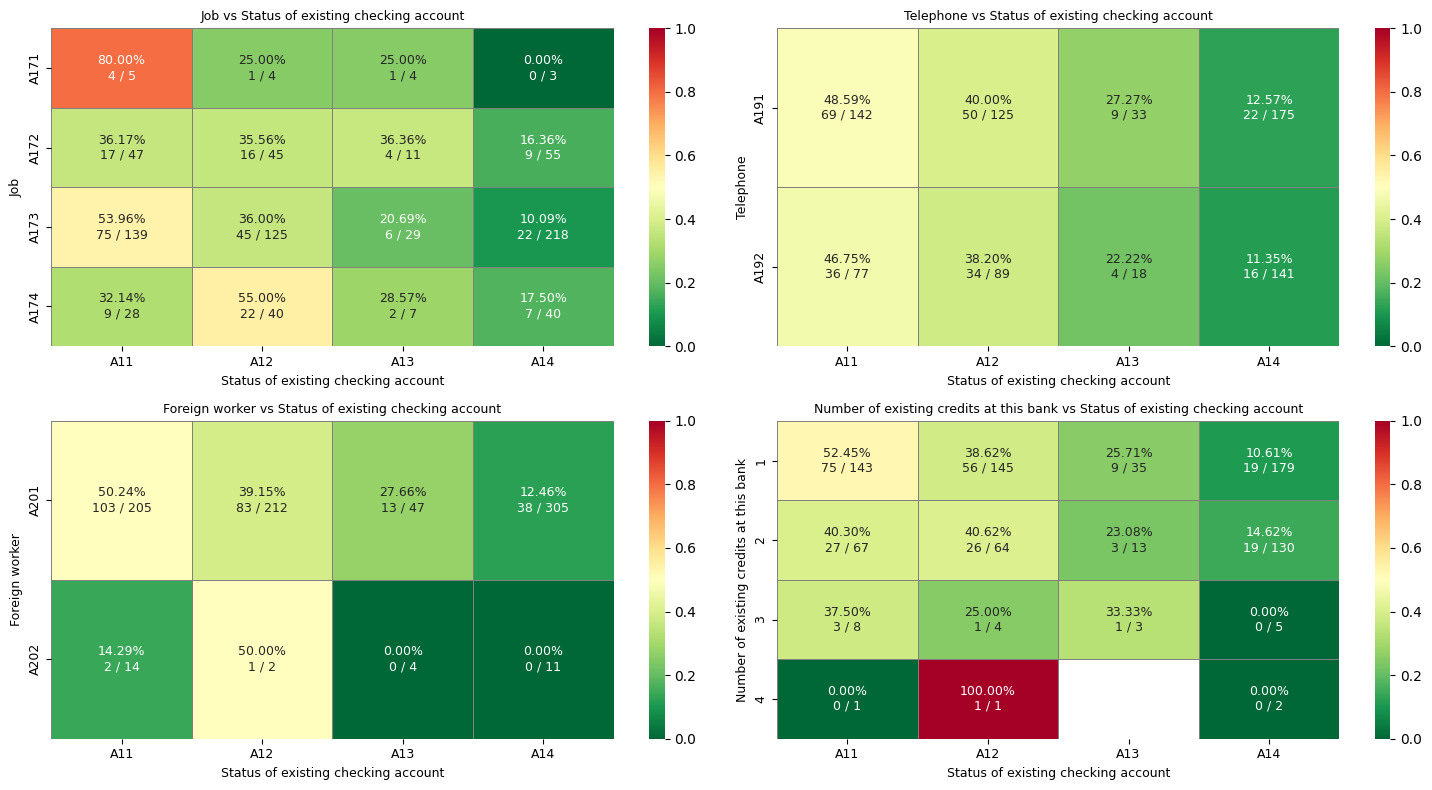

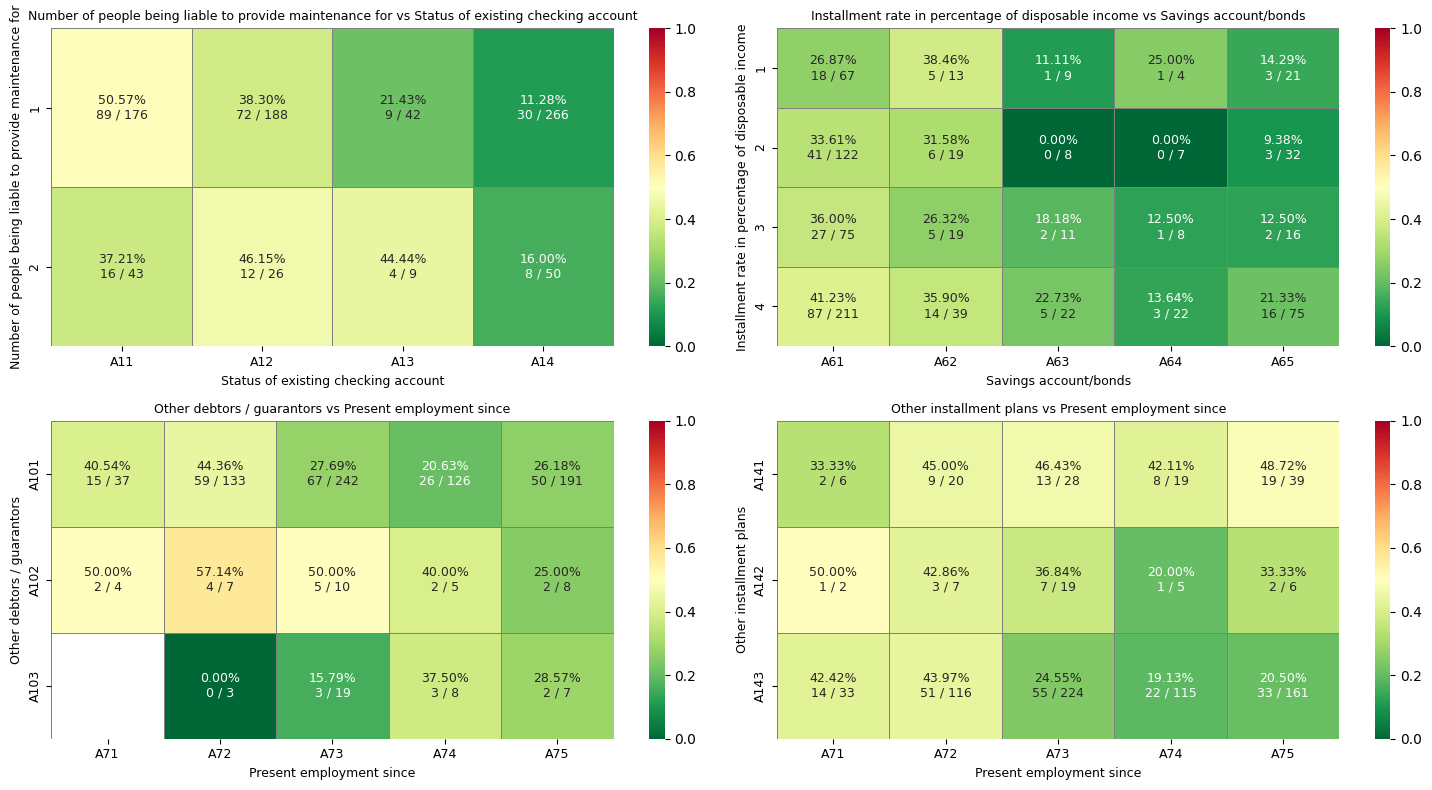

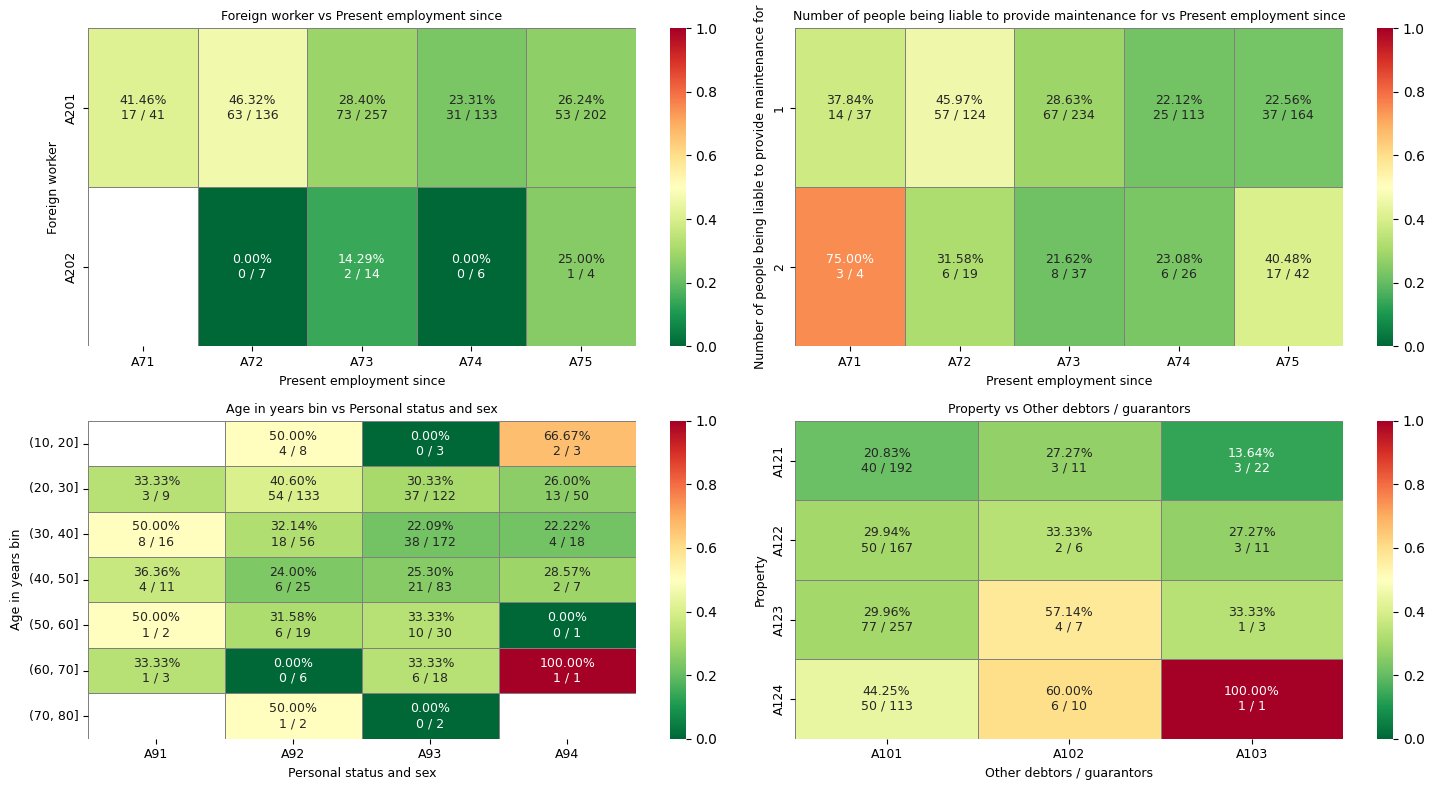

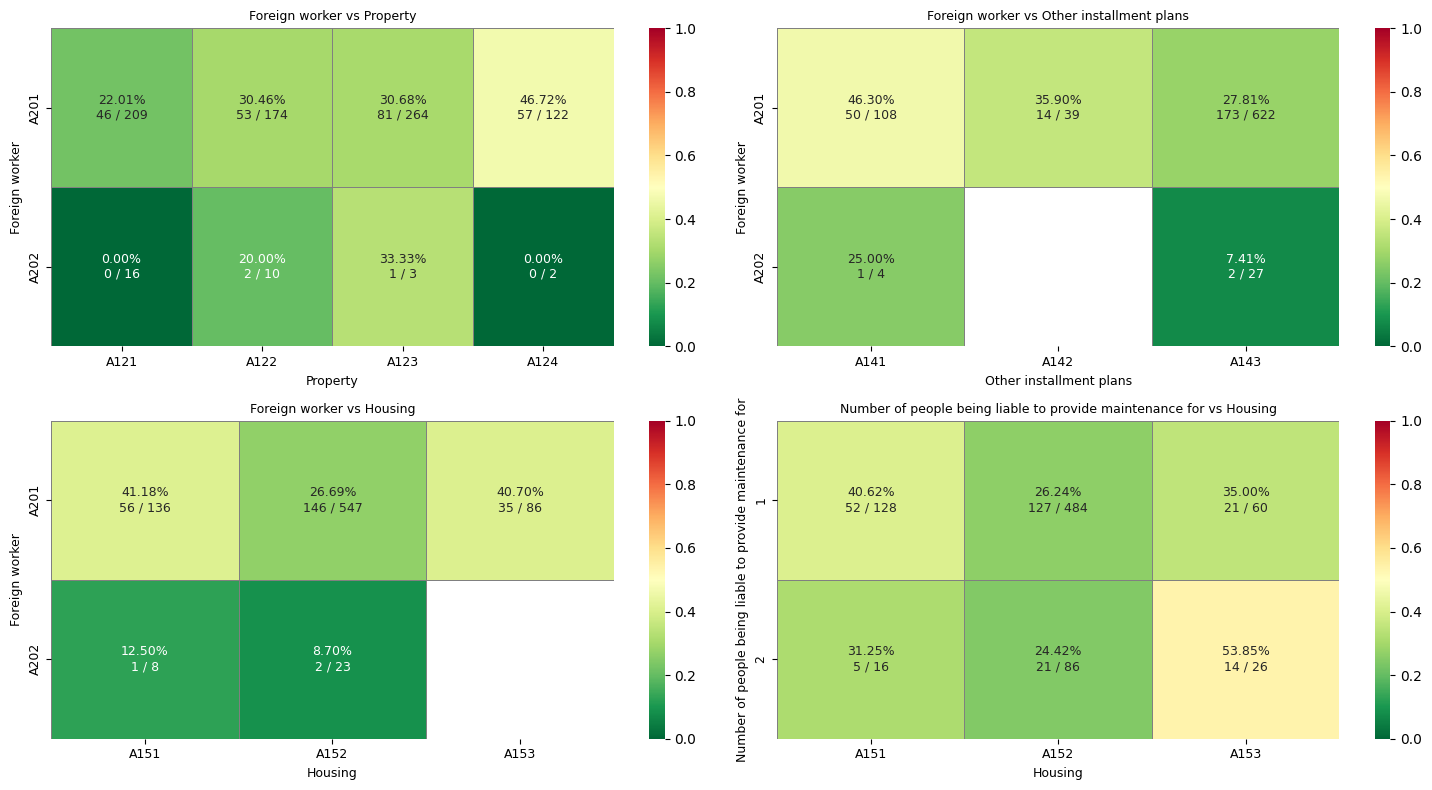

In [29]:
# Plotting the heatmaps in batches of 4
batch_size = 4

for i in range(0, len(valid_pairs), batch_size):
    batch = valid_pairs[i:i+batch_size]

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    axes = axes.flatten()

    for ax, (feature_x, feature_y) in zip(axes, batch):
        plot_bad_loans_rate_heatmap(
            train_df,
            feature_x,
            feature_y,
            ax=ax,
            fontsize=9
        )

    for j in range(len(batch), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

#### Pearsons Correlation Heatmap (for numerical features)
- Shows low correlation among numerical (and ordinal/numerical-like) features
- Credit amount and Duration in months exhibit a somewhat stronger correlation, which is intuitive

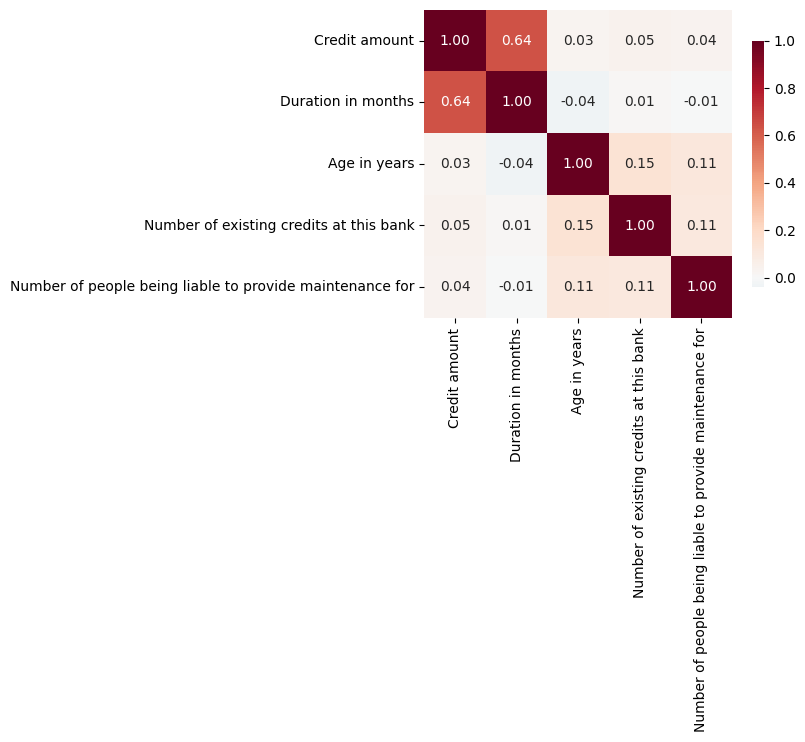

In [30]:
train_df_copy = train_df.copy()
train_df_copy = train_df_copy[["Credit amount", 
                               "Duration in months", 
                               "Age in years", 
                               "Number of existing credits at this bank", 
                               "Number of people being liable to provide maintenance for"]]


corr = train_df_copy.select_dtypes(include="number").corr(method="pearson")

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True, 
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.show()

#### Cramer's V Heatmap
- Displays very weak associations between categorical (or binned numerical) features
- The only notable exception is the pair Housing – Property, which is expected given their conceptual overlap

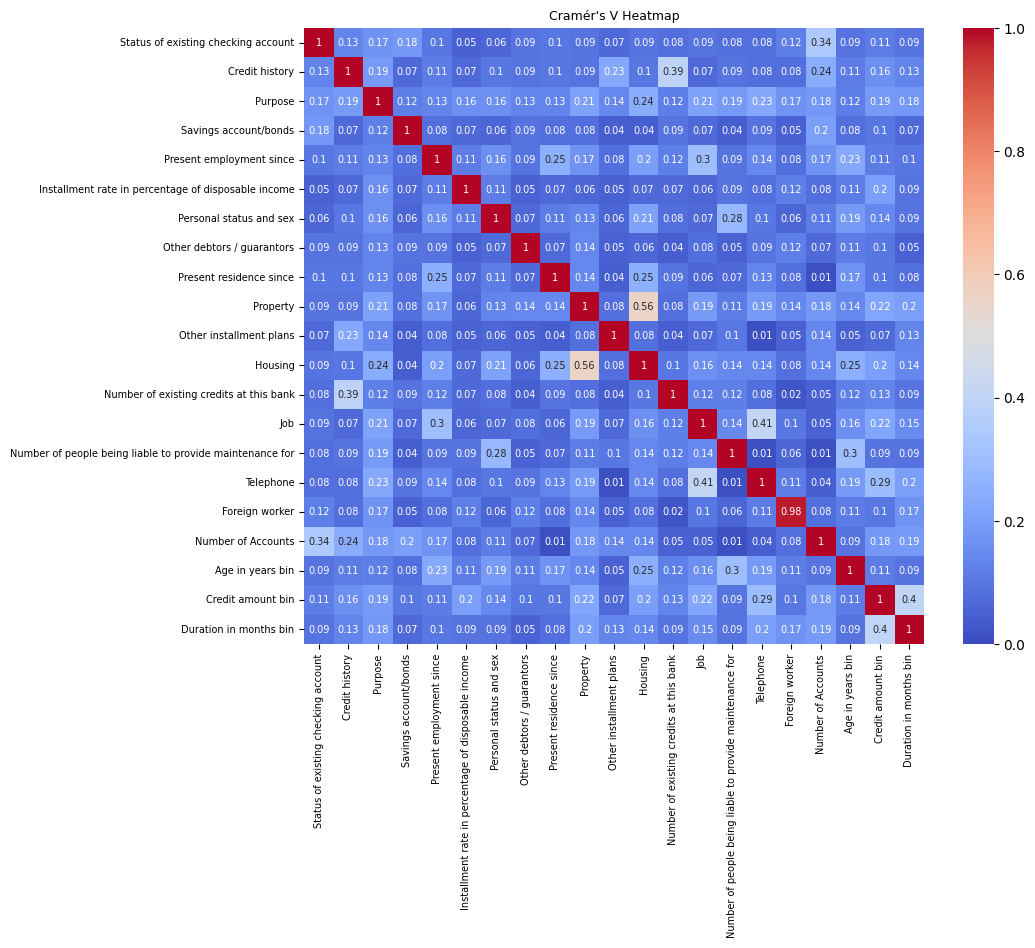

In [31]:

train_df_copy = train_df.copy()
cols_to_remove = ["Credit risk", "Duration in months", "Age in years", "Credit amount"]
train_df_copy = train_df_copy.drop(columns=cols_to_remove)
train_df_copy = train_df_copy.astype("object")

plot_cramers_v_heatmap(train_df_copy)

#### Monthly Payment
- This is a constructed feature (Credit Amount / Duration in months)
- This interaction seems to show falling bad loan rate (from 36% to 18%) as the monthly payment increases
- Bins with monthly payment over 400 are too small and very noisy
- Overall this interaction seems to have prediciton power

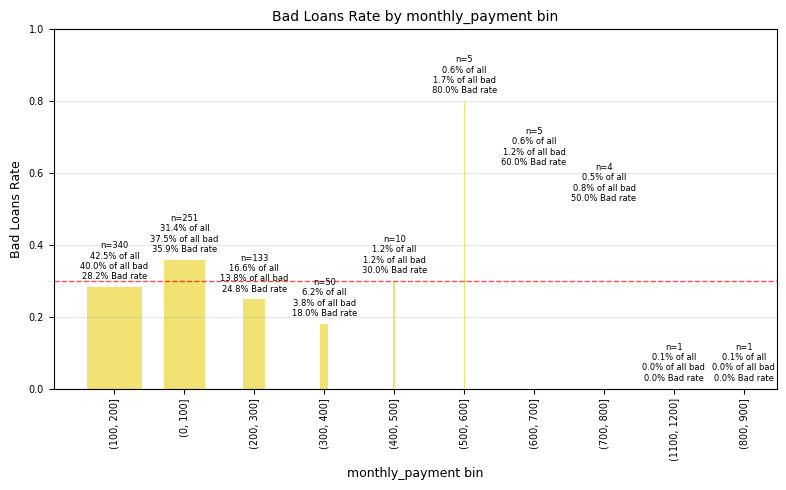

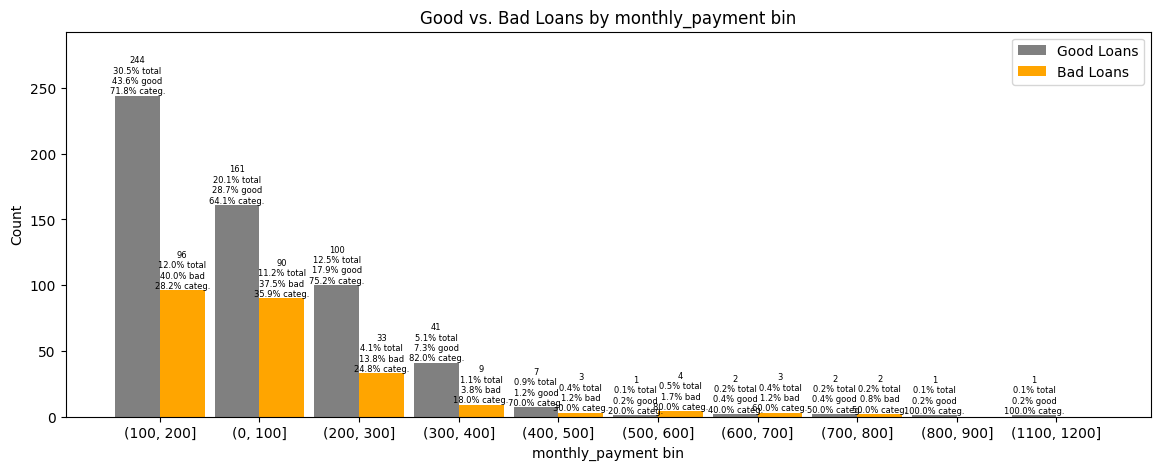

In [32]:
train_df["monthly_payment"]  = train_df["Credit amount"] / train_df["Duration in months"]
train_df["monthly_payment bin"] = pd.cut(train_df[ "monthly_payment"], bins=range(0, int(train_df[ "monthly_payment"].max()) + 100, 100))

plot_bars_rel(df = train_df, 
                        feature = "monthly_payment bin", 
                        bucket_size=10, 
                        figsize=(8,5),
                        hline=0.3,
                        feature_type="categorical")

plot_bars_abs(df = train_df, 
                      feature = "monthly_payment bin", 
                      figsize=(14,5),
                      label_fontsize=6,
                      )